<a href="https://colab.research.google.com/github/dsatish1252/sqlite-python-implementation/blob/main/Employee_Salary_predection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Uncomment if required

!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display graphs inside Colab
%matplotlib inline

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
np.random.seed(42)

education_levels = ["Bachelor","Master","PhD"]

job_roles = [
    "Analyst",
    "Developer",
    "Manager",
    "Data Scientist",
    "Consultant"
]

cities = [
    "Bangalore",
    "Hyderabad",
    "Pune",
    "Delhi",
    "Mumbai"
]

rows = []

for i in range(1,5001):

    age = np.random.randint(22,50)

    experience = np.random.randint(1,21)

    education = np.random.choice(
        education_levels,
        p=[0.5,0.35,0.15]
    )

    role = np.random.choice(job_roles)

    city = np.random.choice(cities)

    skill = np.random.randint(50,100)

    certifications = np.random.randint(0,8)

    rating = round(np.random.uniform(2.5,5.0),1)

    salary = (
        300000 +
        experience*65000 +
        skill*4000 +
        certifications*30000 +
        rating*25000
    )

    if education=="Master":
        salary += 200000

    elif education=="PhD":
        salary += 500000

    if role=="Developer":
        salary += 100000

    elif role=="Manager":
        salary += 350000

    elif role=="Data Scientist":
        salary += 400000

    elif role=="Consultant":
        salary += 150000

    salary += np.random.randint(-50000,50000)

    rows.append([
        i,
        age,
        experience,
        education,
        role,
        city,
        skill,
        certifications,
        rating,
        int(salary)
    ])

columns = [
    "Employee_ID",
    "Age",
    "Years_Experience",
    "Education_Level",
    "Job_Role",
    "City",
    "Skill_Score",
    "Certifications",
    "Previous_Company_Rating",
    "Salary"
]

df = pd.DataFrame(rows,columns=columns)

df.head()

,Employee_ID,Age,Years_Experience,Education_Level,Job_Role,City,Skill_Score,Certifications,Previous_Company_Rating,Salary
0,1,28,20,PhD,Manager,Mumbai,70,6,3.6,2987194
1,2,32,4,Bachelor,Manager,Mumbai,51,7,4.6,1456969
2,3,49,1,Bachelor,Consultant,Delhi,74,0,3.8,940478
3,4,31,16,Bachelor,Manager,Delhi,52,4,4.0,2164276
4,5,30,7,Bachelor,Analyst,Delhi,63,1,3.5,1098397


In [5]:
df.to_csv("employee_salary_dataset.csv",index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [6]:
df = pd.read_csv("employee_salary_dataset.csv")

df.head()

,Employee_ID,Age,Years_Experience,Education_Level,Job_Role,City,Skill_Score,Certifications,Previous_Company_Rating,Salary
0,1,28,20,PhD,Manager,Mumbai,70,6,3.6,2987194
1,2,32,4,Bachelor,Manager,Mumbai,51,7,4.6,1456969
2,3,49,1,Bachelor,Consultant,Delhi,74,0,3.8,940478
3,4,31,16,Bachelor,Manager,Delhi,52,4,4.0,2164276
4,5,30,7,Bachelor,Analyst,Delhi,63,1,3.5,1098397


In [7]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(5000, 10)


In [8]:
df.head()


,Employee_ID,Age,Years_Experience,Education_Level,Job_Role,City,Skill_Score,Certifications,Previous_Company_Rating,Salary
0,1,28,20,PhD,Manager,Mumbai,70,6,3.6,2987194
1,2,32,4,Bachelor,Manager,Mumbai,51,7,4.6,1456969
2,3,49,1,Bachelor,Consultant,Delhi,74,0,3.8,940478
3,4,31,16,Bachelor,Manager,Delhi,52,4,4.0,2164276
4,5,30,7,Bachelor,Analyst,Delhi,63,1,3.5,1098397


In [9]:
df.tail()

,Employee_ID,Age,Years_Experience,Education_Level,Job_Role,City,Skill_Score,Certifications,Previous_Company_Rating,Salary
4995,4996,27,13,PhD,Analyst,Delhi,61,1,4.0,2009459
4996,4997,25,8,Bachelor,Consultant,Delhi,93,0,3.5,1393706
4997,4998,36,9,Bachelor,Manager,Hyderabad,88,0,4.1,1644434
4998,4999,40,16,Master,Manager,Hyderabad,83,4,3.5,2390805
4999,5000,42,11,Bachelor,Developer,Delhi,52,2,4.3,1457531


In [10]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Years_Experience', 'Education_Level', 'Job_Role',
       'City', 'Skill_Score', 'Certifications', 'Previous_Company_Rating',
       'Salary'],
      dtype='object')


In [11]:
df.dtypes

,0
Employee_ID,int64
Age,int64
Years_Experience,int64
Education_Level,object
Job_Role,object
City,object
Skill_Score,int64
Certifications,int64
Previous_Company_Rating,float64
Salary,int64


In [12]:
target = "Salary"

print("Target Variable :",target)

Target Variable : Salary


In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['Employee_ID', 'Age', 'Years_Experience', 'Skill_Score',
       'Certifications', 'Previous_Company_Rating', 'Salary'],
      dtype='object')


In [15]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['Education_Level', 'Job_Role', 'City'], dtype='object')


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              5000 non-null   int64  
 1   Age                      5000 non-null   int64  
 2   Years_Experience         5000 non-null   int64  
 3   Education_Level          5000 non-null   object 
 4   Job_Role                 5000 non-null   object 
 5   City                     5000 non-null   object 
 6   Skill_Score              5000 non-null   int64  
 7   Certifications           5000 non-null   int64  
 8   Previous_Company_Rating  5000 non-null   float64
 9   Salary                   5000 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 390.8+ KB


In [17]:
df.describe()

,Employee_ID,Age,Years_Experience,Skill_Score,Certifications,Previous_Company_Rating,Salary
count,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,2500.500000,35.56480,10.625200,74.389000,3.503000,3.768560,1.830961e+06
std,1443.520003,7.99068,5.755567,14.418116,2.279787,0.725132,4.513416e+05
min,1.000000,22.00000,1.000000,50.000000,0.000000,2.500000,7.294130e+05
25%,1250.750000,29.00000,6.000000,62.000000,2.000000,3.200000,1.481294e+06
50%,2500.500000,36.00000,11.000000,74.000000,4.000000,3.800000,1.833290e+06
75%,3750.250000,42.00000,16.000000,87.000000,5.000000,4.400000,2.173777e+06
max,5000.000000,49.00000,20.000000,99.000000,7.000000,5.000000,3.134961e+06


In [18]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Years_Experience,0
Education_Level,0
Job_Role,0
City,0
Skill_Score,0
Certifications,0
Previous_Company_Rating,0
Salary,0


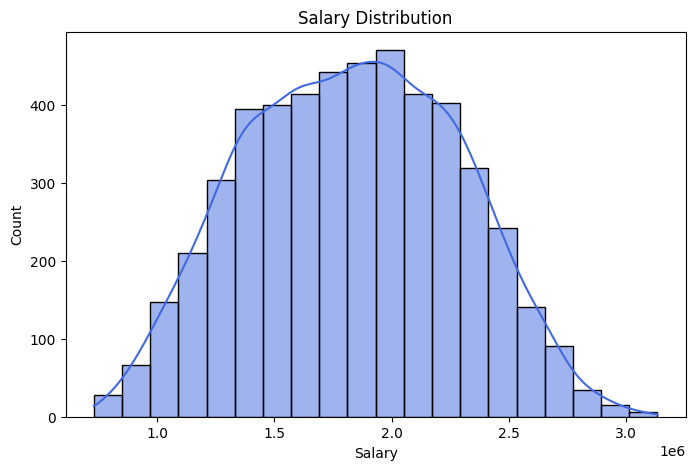

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"],bins=20,kde=True,color="royalblue")

plt.title("Salary Distribution")

plt.show()

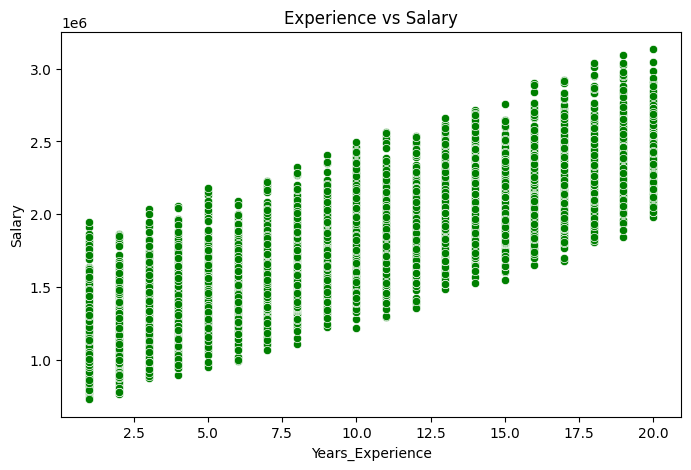

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Years_Experience",
    y="Salary",
    data=df,
    color="green"
)

plt.title("Experience vs Salary")

plt.show()

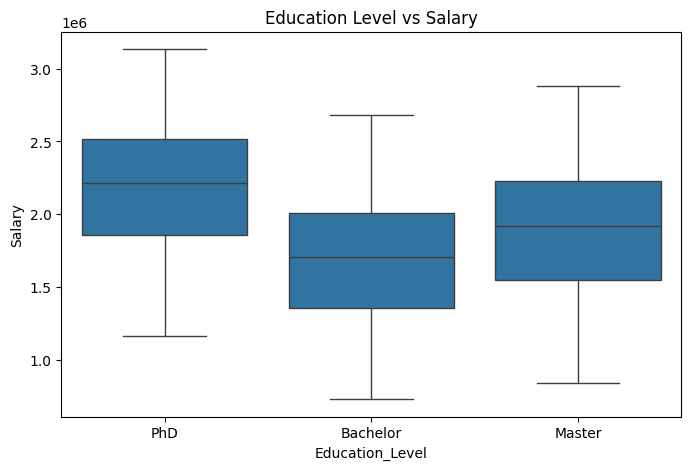

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Education_Level",
    y="Salary",
    data=df
)

plt.title("Education Level vs Salary")

plt.show()

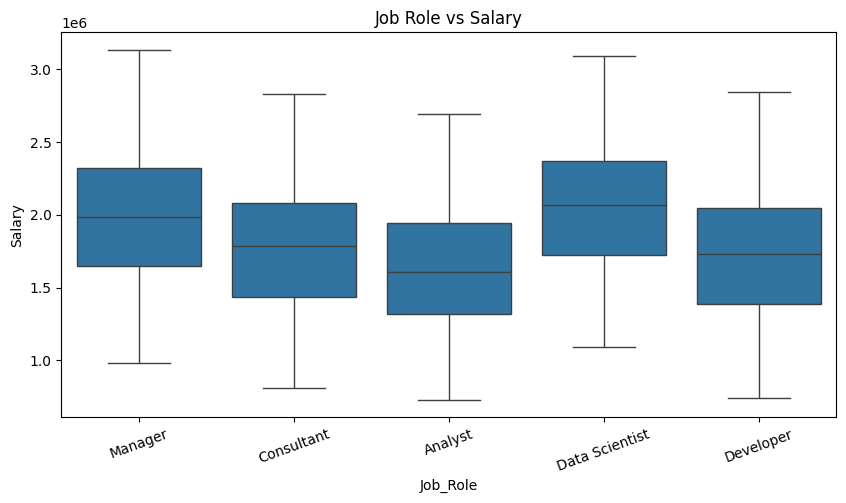

In [22]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Job_Role",
    y="Salary",
    data=df
)

plt.xticks(rotation=20)

plt.title("Job Role vs Salary")

plt.show()

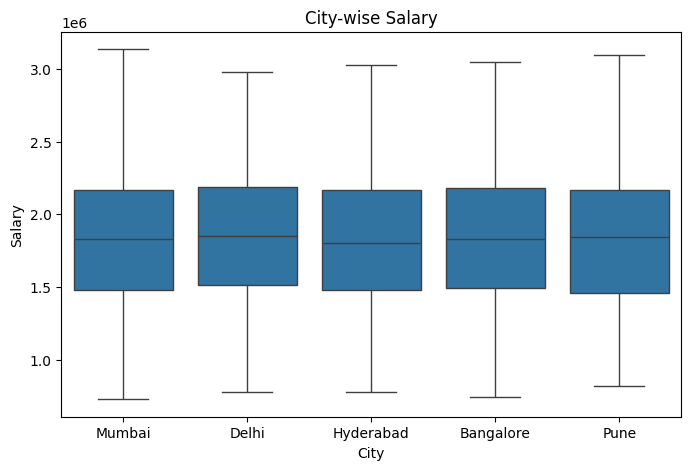

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="City",
    y="Salary",
    data=df
)

plt.title("City-wise Salary")

plt.show()

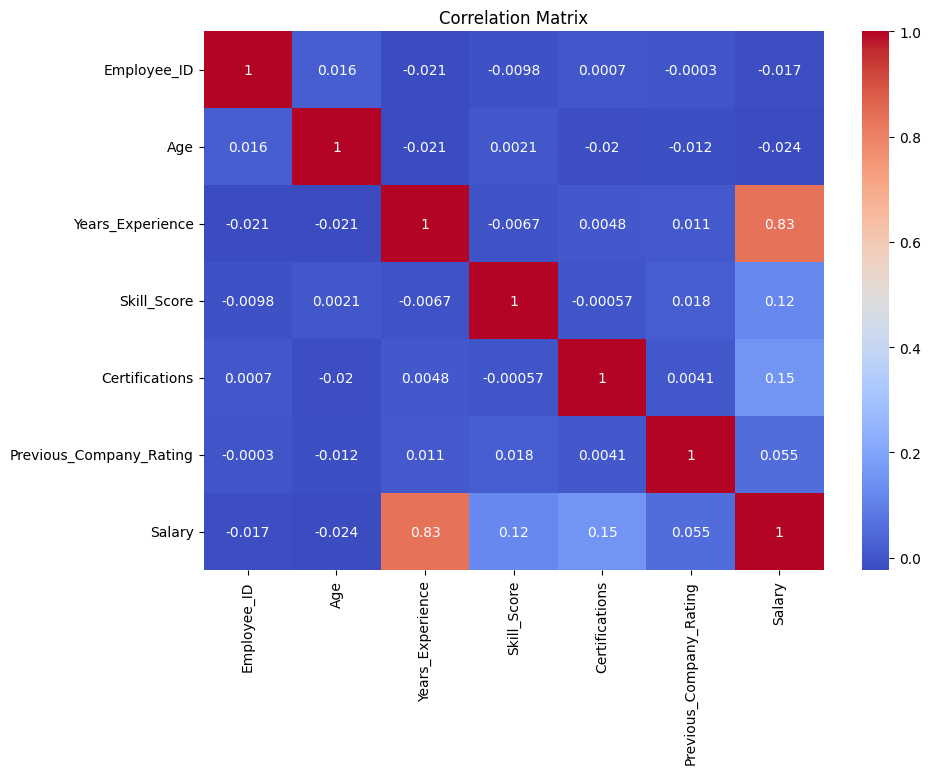

In [24]:
plt.figure(figsize=(10,7))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

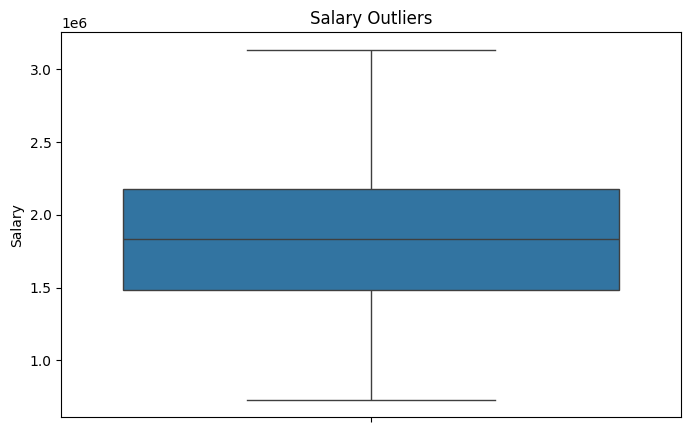

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["Salary"]
)

plt.title("Salary Outliers")

plt.show()

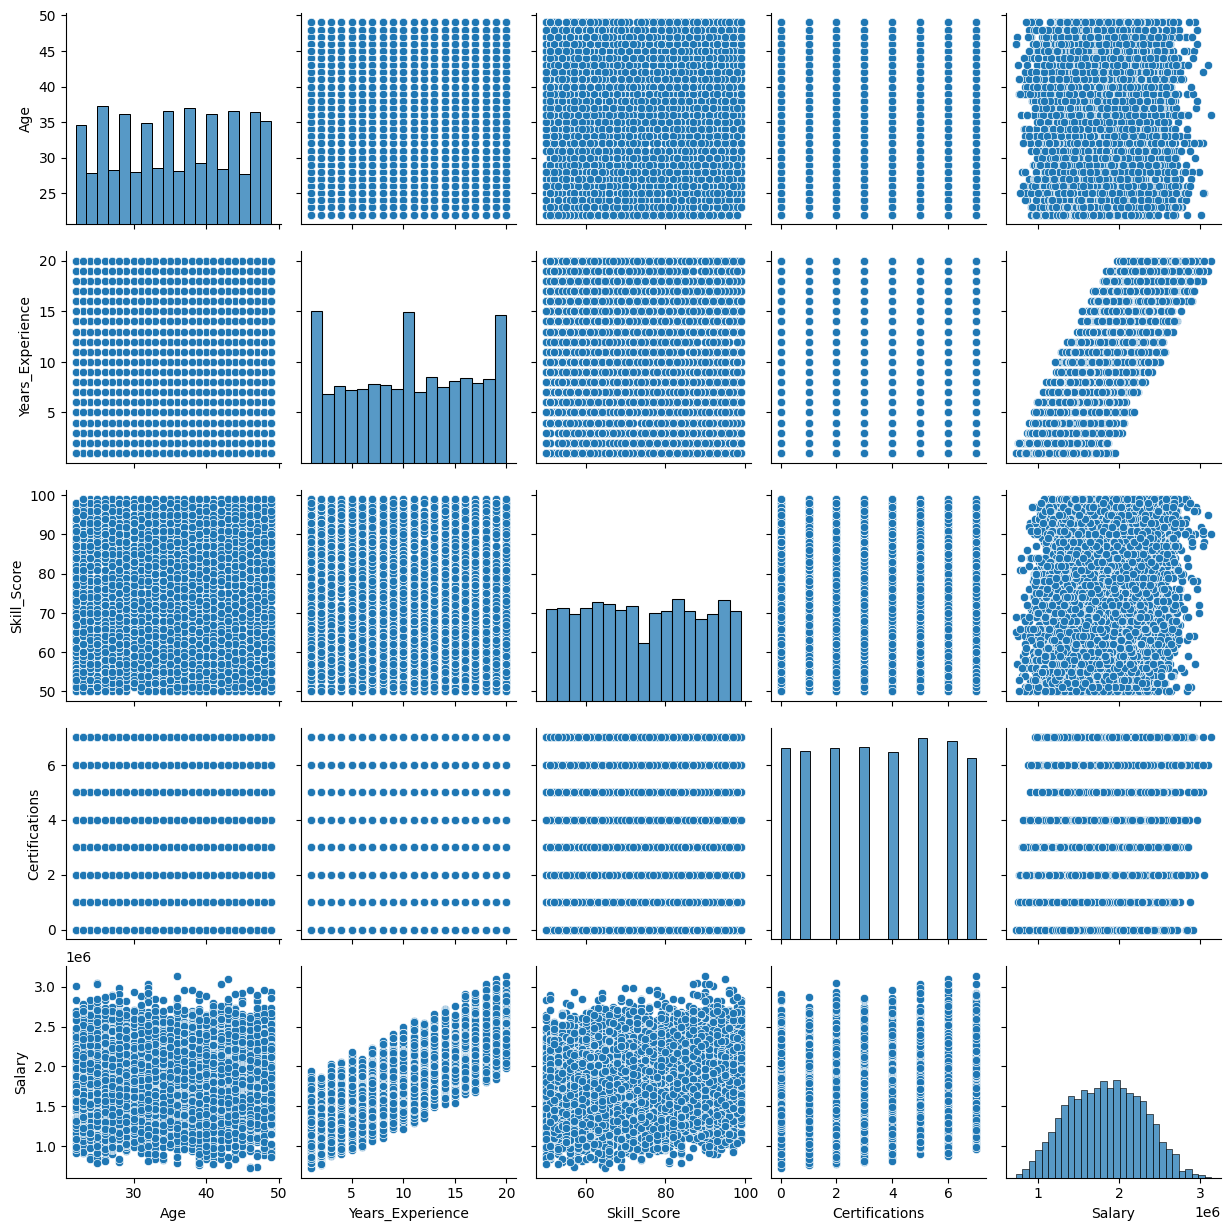

In [26]:
sns.pairplot(
    df[
        [
            "Age",
            "Years_Experience",
            "Skill_Score",
            "Certifications",
            "Salary"
        ]
    ]
)

plt.show()

In [27]:
# Task 4: Data Preprocessing

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [28]:
# Separate input features and target variable

X = df.drop(columns=["Salary"])

y = df["Salary"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (5000, 9)
Target Shape : (5000,)


In [29]:
numerical_features = [
    "Age",
    "Years_Experience",
    "Skill_Score",
    "Certifications",
    "Previous_Company_Rating"
]

categorical_features = [
    "Education_Level",
    "Job_Role",
    "City"
]

print("Numerical Features")
print(numerical_features)

print("\nCategorical Features")
print(categorical_features)

Numerical Features
['Age', 'Years_Experience', 'Skill_Score', 'Certifications', 'Previous_Company_Rating']

Categorical Features
['Education_Level', 'Job_Role', 'City']


In [30]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_features
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )

    ],

    remainder="drop"

)

print("Preprocessing Pipeline Created Successfully!")

Preprocessing Pipeline Created Successfully!


In [31]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (4000, 9)
Testing Features : (1000, 9)
Training Target : (4000,)
Testing Target : (1000,)


In [32]:
from sklearn.dummy import DummyRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [33]:
dummy_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", DummyRegressor(strategy="mean"))

])

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

In [34]:
dummy_mae = mean_absolute_error(
    y_test,
    dummy_predictions
)

dummy_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        dummy_predictions
    )
)

dummy_r2 = r2_score(
    y_test,
    dummy_predictions
)

print("Dummy Regressor Performance")

print("MAE :", round(dummy_mae,2))
print("RMSE :", round(dummy_rmse,2))
print("R² Score :", round(dummy_r2,4))

Dummy Regressor Performance
MAE : 374105.92
RMSE : 449444.24
R² Score : -0.0004


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.ensemble import RandomForestRegressor

In [36]:
linear_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", LinearRegression())

])

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [37]:
ridge_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", Ridge(alpha=1.0))

])

ridge_model.fit(
    X_train,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test
)

print("Ridge Regression Model Trained Successfully!")

Ridge Regression Model Trained Successfully!


In [38]:
lasso_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model", Lasso(alpha=1.0))

])

lasso_model.fit(
    X_train,
    y_train
)

lasso_predictions = lasso_model.predict(
    X_test
)

print("Lasso Regression Model Trained Successfully!")

Lasso Regression Model Trained Successfully!


In [39]:
rf_model = Pipeline([

    ("preprocessor", preprocessor),

    ("model",

        RandomForestRegressor(

            n_estimators=100,

            random_state=42

        )

    )

])

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [40]:
def evaluate_model(model_name, actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    r2 = r2_score(actual, predicted)

    return [

        model_name,

        round(mae,2),

        round(rmse,2),

        round(r2,4)

    ]

In [41]:
results = []

results.append(
    evaluate_model(
        "Dummy Regressor",
        y_test,
        dummy_predictions
    )
)

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Ridge Regression",
        y_test,
        ridge_predictions
    )
)

results.append(
    evaluate_model(
        "Lasso Regression",
        y_test,
        lasso_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

In [42]:
comparison = pd.DataFrame(

    results,

    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]

)

comparison

,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,374105.92,449444.24,-0.0004
1,Linear Regression,24660.49,28544.39,0.9960
2,Ridge Regression,24670.53,28553.83,0.9960
3,Lasso Regression,24660.62,28544.37,0.9960
4,Random Forest,42432.65,54089.87,0.9855


In [43]:
print("Model Performance Comparison")

display(comparison)

Model Performance Comparison


,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,374105.92,449444.24,-0.0004
1,Linear Regression,24660.49,28544.39,0.9960
2,Ridge Regression,24670.53,28553.83,0.9960
3,Lasso Regression,24660.62,28544.37,0.9960
4,Random Forest,42432.65,54089.87,0.9855


In [44]:
best_model = comparison.loc[comparison["R2 Score"].idxmax()]

print("Best Model")
print(best_model)

Best Model
Model       Linear Regression
MAE                  24660.49
RMSE                 28544.39
R2 Score                0.996
Name: 1, dtype: object


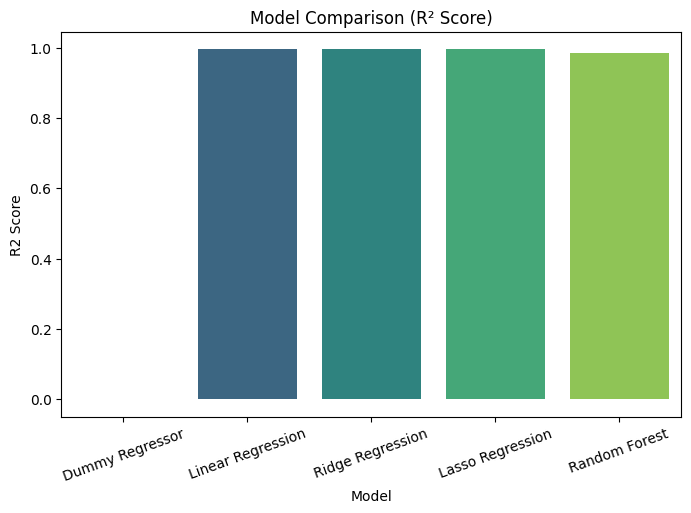

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R2 Score",
    palette="viridis"
)

plt.title("Model Comparison (R² Score)")
plt.xticks(rotation=20)
plt.show()

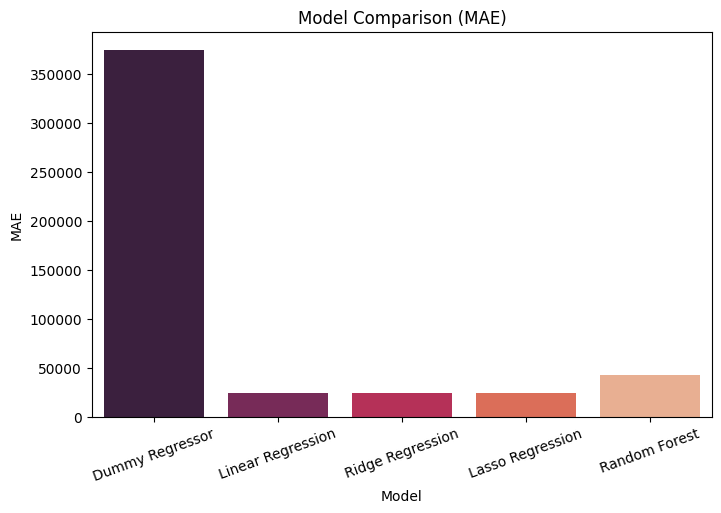

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    palette="rocket"
)

plt.title("Model Comparison (MAE)")
plt.xticks(rotation=20)
plt.show()

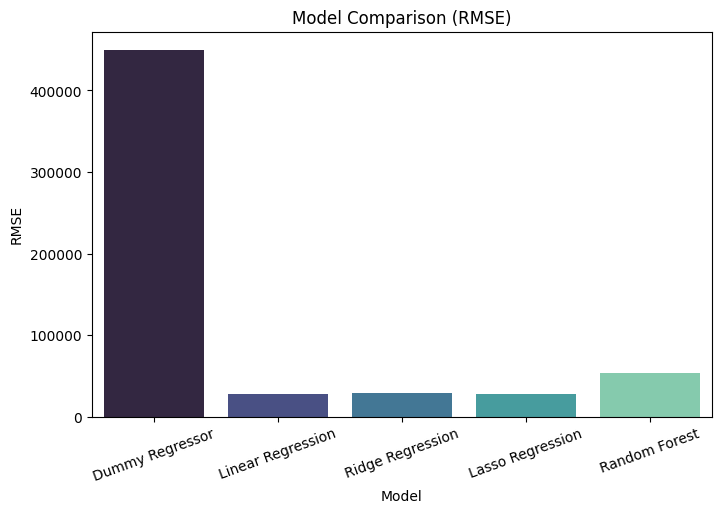

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    palette="mako"
)

plt.title("Model Comparison (RMSE)")
plt.xticks(rotation=20)
plt.show()

In [48]:
lowest_mae = comparison.loc[comparison["MAE"].idxmin()]
lowest_rmse = comparison.loc[comparison["RMSE"].idxmin()]
highest_r2 = comparison.loc[comparison["R2 Score"].idxmax()]

print("Model with Lowest MAE")
print(lowest_mae)

print("\nModel with Lowest RMSE")
print(lowest_rmse)

print("\nModel with Highest R² Score")
print(highest_r2)

Model with Lowest MAE
Model       Linear Regression
MAE                  24660.49
RMSE                 28544.39
R2 Score                0.996
Name: 1, dtype: object

Model with Lowest RMSE
Model       Lasso Regression
MAE                 24660.62
RMSE                28544.37
R2 Score               0.996
Name: 3, dtype: object

Model with Highest R² Score
Model       Linear Regression
MAE                  24660.49
RMSE                 28544.39
R2 Score                0.996
Name: 1, dtype: object


In [51]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

In [52]:
param_grid = {

    "model__n_estimators":[50,100,200],

    "model__max_depth":[5,10,15],

    "model__min_samples_split":[2,5,10]

}

In [53]:
grid_search = GridSearchCV(

    estimator=rf_pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid_search.fit(X_train,y_train)

print("Grid Search Completed!")

Grid Search Completed!


In [54]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [55]:
print("Best Cross Validation R² Score")

print(round(grid_search.best_score_,4))

Best Cross Validation R² Score
0.9852


In [56]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

mae = mean_absolute_error(
    y_test,
    best_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

r2 = r2_score(
    y_test,
    best_predictions
)

print("Tuned Random Forest Performance")

print("MAE :",round(mae,2))

print("RMSE :",round(rmse,2))

print("R² :",round(r2,4))

Tuned Random Forest Performance
MAE : 41735.61
RMSE : 53231.49
R² : 0.986


In [57]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

feature_importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":feature_importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

display(importance_df.head(15))

,Feature,Importance
1,num__Years_Experience,0.698509
7,cat__Education_Level_PhD,0.065800
5,cat__Education_Level_Bachelor,0.062940
10,cat__Job_Role_Data Scientist,0.033666
12,cat__Job_Role_Manager,0.029912
8,cat__Job_Role_Analyst,0.025066
3,num__Certifications,0.020742
6,cat__Education_Level_Master,0.020121
2,num__Skill_Score,0.018508
11,cat__Job_Role_Developer,0.007869


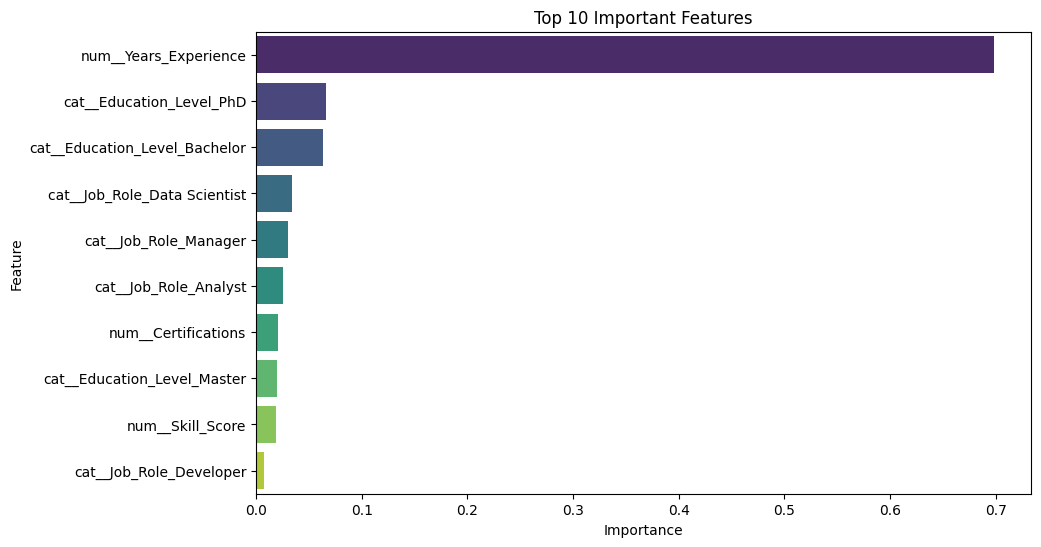

In [58]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 10 Important Features")

plt.show()

In [59]:
new_employee = pd.DataFrame({

    "Employee_ID":[5001],

    "Age":[30],

    "Years_Experience":[6],

    "Education_Level":["Master"],

    "Job_Role":["Data Scientist"],

    "City":["Bangalore"],

    "Skill_Score":[85],

    "Certifications":[3],

    "Previous_Company_Rating":[4.2]

})

In [60]:
predicted_salary = best_model.predict(new_employee)

print("Predicted Salary")

print("₹ {:,.2f}".format(predicted_salary[0]))

Predicted Salary
₹ 1,831,436.37


In [61]:
import joblib

joblib.dump(best_model, "employee_salary_prediction_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


,Task,Status
0,Dataset Created,Completed
1,EDA Completed,Completed
2,Preprocessing,Completed
3,Train-Test Split,Completed
4,Dummy Regressor,Completed
5,Linear Regression,Completed
6,Ridge Regression,Completed
7,Lasso Regression,Completed
8,Random Forest,Completed
9,Hyperparameter Tuning,Completed
